In [6]:
!pip install -U datasets transformers accelerate evaluate sentencepiece tokenizers huggingface-hub peft shap tqdm pyarrow

In [8]:
import os
import glob

print("Current working dir:", os.getcwd())
print("Local files that may conflict:")
for p in glob.glob("datasets*"):
    print(" -", p)

Current working dir: /content
Local files that may conflict:


In [9]:
import os
import shutil
import sys

TARGET = "/content/ftsite"
FLAG1 = os.path.join(TARGET, ".installed_revised")
FLAG2 = os.path.join(TARGET, ".installed_revised_ok")

# remove cached install flags
for f in [FLAG1, FLAG2]:
    if os.path.exists(f):
        os.remove(f)
        print("Removed flag:", f)

# remove only broken HF-related packages
for name in ["datasets", "transformers", "pyarrow_hotfix", "pyarrow"]:
    path = os.path.join(TARGET, name)
    if os.path.exists(path):
        shutil.rmtree(path, ignore_errors=True)
        print("Removed:", path)

# also remove matching dist-info folders
for item in os.listdir(TARGET):
    lower = item.lower()
    if lower.startswith(("datasets-", "transformers-", "pyarrow-", "pyarrow_hotfix-", "pyarrow_hotfix.")) or "pyarrow_hotfix" in lower:
        full = os.path.join(TARGET, item)
        if os.path.isdir(full):
            shutil.rmtree(full, ignore_errors=True)
        else:
            os.remove(full)
        print("Removed:", full)

print("Cleanup complete.")

Removed: /content/ftsite/datasets
Removed: /content/ftsite/transformers
Removed: /content/ftsite/pyarrow_hotfix
Removed: /content/ftsite/pyarrow
Removed: /content/ftsite/datasets-2.20.0.dist-info
Removed: /content/ftsite/pyarrow-23.0.1.dist-info
Removed: /content/ftsite/transformers-5.3.0.dist-info
Removed: /content/ftsite/datasets-4.7.0.dist-info
Removed: /content/ftsite/transformers-4.44.2.dist-info
Removed: /content/ftsite/pyarrow_hotfix-0.7.dist-info
Removed: /content/ftsite/pyarrow-19.0.1.dist-info
Cleanup complete.


In [10]:
import subprocess
import sys
import os

TARGET = "/content/ftsite"
os.makedirs(TARGET, exist_ok=True)

def install_one(pkg):
    print(f"Installing {pkg} ...")
    subprocess.run(
        ["python3", "-m", "pip", "install", "-t", TARGET, pkg],
        check=True
    )
    print(f"Done: {pkg}")

install_one("pyarrow==19.0.1")
install_one("pyarrow-hotfix==0.7")
install_one("datasets==2.20.0")
install_one("transformers==4.44.2")

Installing pyarrow==19.0.1 ...
Done: pyarrow==19.0.1
Installing pyarrow-hotfix==0.7 ...
Done: pyarrow-hotfix==0.7
Installing datasets==2.20.0 ...
Done: datasets==2.20.0
Installing transformers==4.44.2 ...
Done: transformers==4.44.2


In [12]:
import os, shutil, sys

TARGET = "/content/ftsite"

# remove broken HF / arrow stack
for name in [
    "datasets",
    "transformers",
    "pyarrow",
    "pyarrow_hotfix",
]:
    path = os.path.join(TARGET, name)
    if os.path.exists(path):
        shutil.rmtree(path, ignore_errors=True)
        print("Removed:", path)

# remove dist-info leftovers
for item in os.listdir(TARGET):
    lower = item.lower()
    if any(k in lower for k in ["datasets", "transformers", "pyarrow"]):
        full = os.path.join(TARGET, item)
        if os.path.isdir(full):
            shutil.rmtree(full, ignore_errors=True)
        else:
            os.remove(full)
        print("Removed:", full)

print("Cleanup finished")

Removed: /content/ftsite/datasets
Removed: /content/ftsite/transformers
Removed: /content/ftsite/pyarrow
Removed: /content/ftsite/pyarrow_hotfix
Removed: /content/ftsite/datasets-2.20.0.dist-info
Removed: /content/ftsite/pyarrow-23.0.1.dist-info
Removed: /content/ftsite/transformers-4.44.2.dist-info
Removed: /content/ftsite/pyarrow_hotfix-0.7.dist-info
Removed: /content/ftsite/pyarrow-19.0.1.dist-info
Cleanup finished


In [1]:
pip install pyarrow==19.0.1 pyarrow-hotfix==0.7 datasets==2.20.0 transformers==4.44.2

  Using cached pyarrow-19.0.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
  Using cached pyarrow_hotfix-0.7-py3-none-any.whl.metadata (3.6 kB)
  Using cached datasets-2.20.0-py3-none-any.whl.metadata (19 kB)
  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
  Using cached fsspec-2024.5.0-py3-none-any.whl.metadata (11 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached pyarrow-19.0.1-cp312-cp312-manylinux_2_28_x86_64.whl (42.1 MB)
Using cached pyarrow_hotfix-0.7-py3-none-any.whl (7.9 kB)
Using cached datasets-2.20.0-py3-none-any.whl (547 kB)
Using cached transformers-4.44.2-py3-none-any.whl (9.5 MB)
Using cached fsspec-2024.5.0-py3-none-any.whl (316 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)


In [2]:
import pyarrow
import pyarrow_hotfix
import datasets
import transformers

print("OK")

OK


In [3]:
import sys
TARGET = "/content/ftsite"

if TARGET in sys.path:
    sys.path.remove(TARGET)
sys.path.insert(0, TARGET)

import pyarrow
import pyarrow_hotfix
print("pyarrow ok")
print("pyarrow_hotfix ok")

import datasets
print("datasets ok:", datasets.__version__)

import transformers
print("transformers ok:", transformers.__version__)

pyarrow ok
pyarrow_hotfix ok
datasets ok: 2.20.0
transformers ok: 4.44.2


Installing dependencies...
Installing numpy==2.0.2 ...
Done: numpy==2.0.2
Installing llvmlite==0.43.0 ...
Done: llvmlite==0.43.0
Installing numba==0.60.0 ...
Done: numba==0.60.0
Installing scipy==1.13.1 ...
Done: scipy==1.13.1
Installing pyarrow==19.0.1 ...
Done: pyarrow==19.0.1
Installing pyarrow-hotfix==0.7 ...
Done: pyarrow-hotfix==0.7
Installing pandas==2.2.2 ...
Done: pandas==2.2.2
Installing scikit-learn==1.5.2 ...
Done: scikit-learn==1.5.2
Installing matplotlib==3.9.2 ...
Done: matplotlib==3.9.2
Installing sentencepiece==0.2.1 ...
Done: sentencepiece==0.2.1
Installing shap==0.46.0 ...
Done: shap==0.46.0
Installing xgboost==2.1.1 ...
Done: xgboost==2.1.1
Installing joblib==1.4.2 ...
Done: joblib==1.4.2
Installing threadpoolctl==3.5.0 ...
Done: threadpoolctl==3.5.0
Installing pillow==10.4.0 ...
Done: pillow==10.4.0
Installing kiwisolver==1.4.5 ...
Done: kiwisolver==1.4.5
Installing contourpy==1.2.1 ...
Done: contourpy==1.2.1
Installing cycler==0.12.1 ...
Done: cycler==0.12.1
Insta

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



=== Predictive Model Comparison ===
                model       auc    acc  threshold
0  LogisticRegression  0.770667  0.696   0.758469
1             XGBoost  0.789943  0.660   0.817356
Saved SHAP summary: /content/results_credit_rag_alignment_v1/shap_summary_xgb.png


Explaining [rag_template]: 100%|██████████| 250/250 [00:03<00:00, 63.57it/s]



=== Structured Explanation Summary ===
      condition  feature_alignment_surface  feature_alignment_rationale  \
0      Template                        1.0                          1.0   
1  RAG-Template                        1.0                          1.0   

   groundedness_v1  groundedness_v2  self_consistency  
0         0.000000         0.000000               1.0  
1         0.560617         0.780308               1.0  


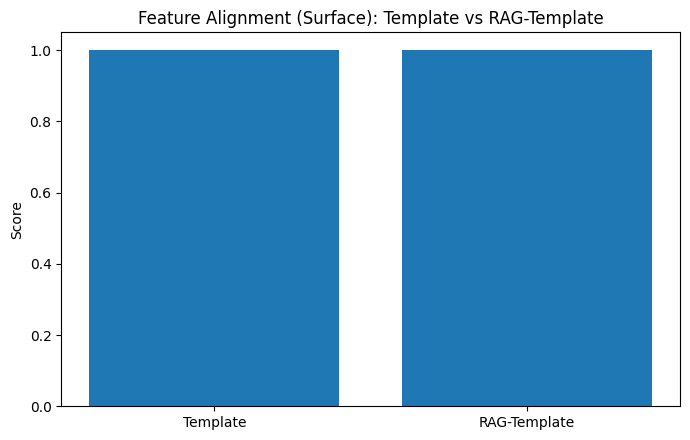

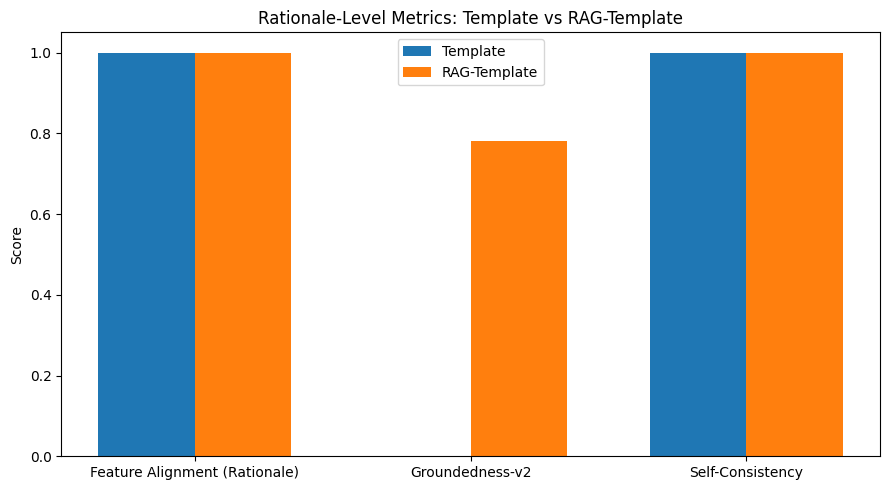


=== Paired t-tests: RAG-Template vs Template ===
feature_alignment_surface: statistic=nan, pvalue=nan
feature_alignment_rationale: statistic=nan, pvalue=nan
groundedness_v2: statistic=2090.6661, pvalue=0
self_consistency: statistic=nan, pvalue=nan

=== Duplicate Report BEFORE Cleaning ===
{'train_unique': 522, 'val_unique': 112, 'test_unique': 114, 'train_val_dup': 1, 'train_test_dup': 1, 'val_test_dup': 0}

=== Duplicate Report AFTER Cleaning ===
{'train_unique': 522, 'val_unique': 111, 'test_unique': 113, 'train_val_dup': 0, 'train_test_dup': 0, 'val_test_dup': 0}


Map:   0%|          | 0/524 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

Map:   0%|          | 0/113 [00:00<?, ? examples/s]

Filter:   0%|          | 0/524 [00:00<?, ? examples/s]

Filter:   0%|          | 0/111 [00:00<?, ? examples/s]

Filter:   0%|          | 0/113 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.027000,0.019902
2,0.010200,0.006636
3,0.009600,0.006447
4,0.008000,0.006295


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='le


=== Base LLM vs Fine-Tuned LLM ===
feature_alignment_rationale_base    0.033333
groundedness_base_v1                0.008921
groundedness_base_v2                0.004460
self_consistency_base               1.000000
feature_alignment_rationale_ft      0.276667
groundedness_ft_v1                  0.237249
groundedness_ft_v2                  0.118625
self_consistency_ft                 1.000000
dtype: float64

QUALITATIVE EXPLANATION COMPARISON

CASE 1

BASE PROMPT:
Write 2 short explanatory sentences using only the applicant factors below.
Do not cite external policy.
Then write exactly one final line: Decision: APPROVE or Decision: DECLINE.

Decision rule: if probability >= 0.817, output APPROVE; else DECLINE.
Probability: 0.915
Driver 1: duration = 6
Driver 2: credit history critical account/other credits existing = critical account/other credits existing
Driver 3: status no checking account = ... < 100 DM

--- Base LLM (Run 1) ---
The following table shows how to use this information

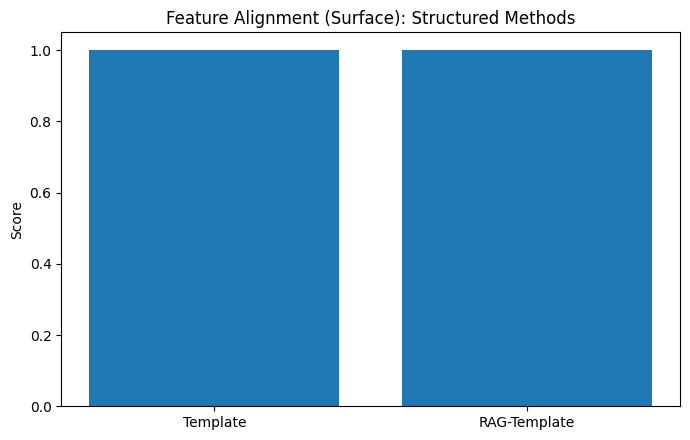

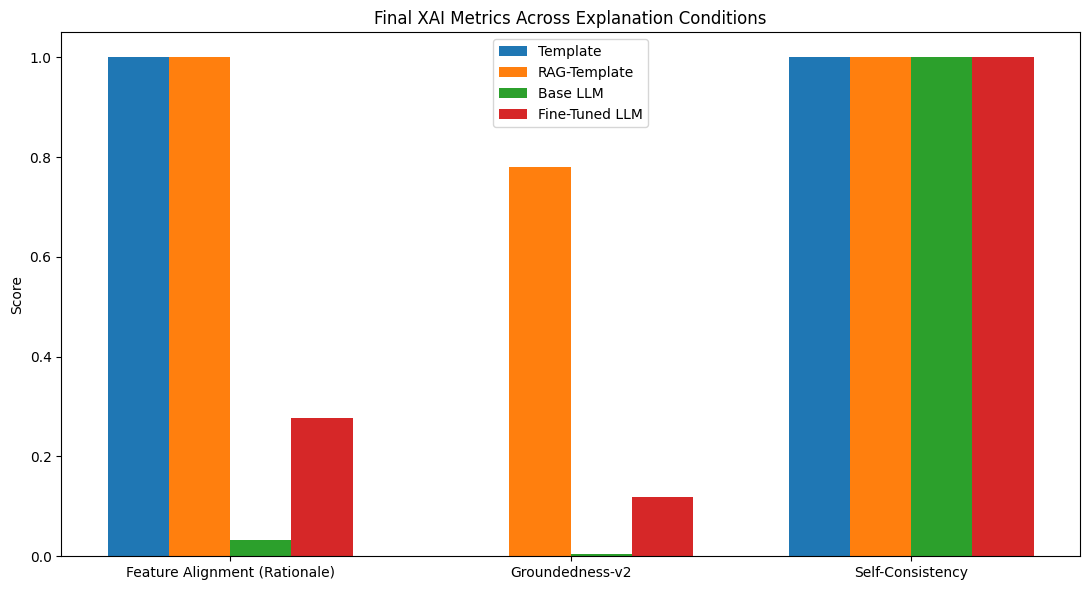


Results dir: /content/results_credit_rag_alignment_v1
Files: ['corpus_stats_rag_template.csv', 'corpus_stats_template.csv', 'duplicate_report_after.csv', 'duplicate_report_before.csv', 'feature_alignment_surface_bar.png', 'final_all_conditions_bar.png', 'final_summary_metrics.csv', 'final_surface_alignment_structured.png', 'finetune_eval_metrics.csv', 'llm_compare_metrics.csv', 'llm_corpus_stats.csv', 'metrics_rag_template.csv', 'metrics_template.csv', 'model_performance.csv', 'rationale_summary_all_conditions.csv', 'shap_summary_xgb.png', 'structured_rationale_metrics_bar.png', 'structured_summary.csv', 'structured_surface_summary.csv', 'structured_ttests.csv']


In [5]:
# ============================================================
# Credit-Risk Explainability + SHAP + RAG + Fine-Tuned LLM
# Full Revised Version with Two Feature-Alignment Definitions
# ============================================================

# Framework:
# 1. Logistic Regression as interpretable benchmark
# 2. Compare predictive performance with XGBoost
# 3. Use SHAP on XGBoost to extract top feature attributions
# 4. Use those attributions for policy retrieval (RAG)
# 5. Compare Template vs RAG-Template on:
#    - Feature Alignment (Surface)
#    - Feature Alignment (Rationale)
#    - Groundedness
#    - Self-Consistency
# 6. Fine-tune local LLM only as verbalizer of RAG-template
# 7. Compare Base LLM (no RAG prompt) vs Fine-Tuned LLM
# 8. Final summary across four conditions uses:
#    - Feature Alignment (Rationale)
#    - Groundedness-v2
#    - Self-Consistency
#
# Key methodological choice:
# - Surface alignment applies only to structured methods:
#   Template / RAG-Template
# - Rationale alignment applies to all four conditions:
#   Template / RAG-Template / Base LLM / Fine-Tuned LLM
# ============================================================

# ============================================================
# 1. Dependencies
# ============================================================

import os
import sys
import json
import math
import random
import hashlib
import inspect
import warnings
import contextlib
import subprocess
import re
import shutil

# ------------------------------------------------------------
# Recommended in Colab:
# Use normal pip instead of custom target installs if possible.
# If you prefer custom target, keep this block.
# ------------------------------------------------------------

TARGET = "/content/ftsite"
FLAG = os.path.join(TARGET, ".installed_credit_rag_alignment_v1")
os.makedirs(TARGET, exist_ok=True)

if TARGET in sys.path:
    sys.path.remove(TARGET)
sys.path.insert(0, TARGET)

def pip_install(*pkgs, no_deps=False, quiet=False):
    for pkg in pkgs:
        cmd = ["python3", "-m", "pip", "install", "-t", TARGET]
        if no_deps:
            cmd.append("--no-deps")
        cmd.append(pkg)
        print(f"Installing {pkg} ...")
        subprocess.run(
            cmd,
            check=True,
            stdout=subprocess.DEVNULL if quiet else None,
            stderr=subprocess.DEVNULL if quiet else None,
        )
        print(f"Done: {pkg}")

def verify_critical_imports():
    import numpy
    import pandas
    import scipy
    import pyarrow
    import pyarrow_hotfix
    import datasets
    import transformers
    import shap
    import xgboost
    print("All critical imports verified.")

if not os.path.exists(FLAG):
    print("Installing dependencies...")

    pip_install(
        "numpy==2.0.2",
        "llvmlite==0.43.0",
        "numba==0.60.0",
        "scipy==1.13.1",
        "pyarrow==19.0.1",
        "pyarrow-hotfix==0.7",
        "pandas==2.2.2",
        "scikit-learn==1.5.2",
        "matplotlib==3.9.2",
        "sentencepiece==0.2.1",
        "shap==0.46.0",
        "xgboost==2.1.1",
        "joblib==1.4.2",
        "threadpoolctl==3.5.0",
        "pillow==10.4.0",
        "kiwisolver==1.4.5",
        "contourpy==1.2.1",
        "cycler==0.12.1",
        "fonttools==4.53.1",
        "pyparsing==3.1.2",
        "datasets==2.20.0",
        "transformers==4.44.2",
        "accelerate==0.33.0",
        "evaluate==0.4.2",
        "huggingface-hub==0.36.0",
        "tokenizers==0.19.1",
        "peft==0.11.1",
        "tqdm==4.67.1",
        "regex==2025.10.23",
        "safetensors==0.6.2",
        "filelock==3.20.0",
        "packaging==25.0",
        "typing-extensions==4.15.0",
        "requests==2.32.4",
        "urllib3==2.5.0",
        "certifi==2025.10.5",
        "charset-normalizer==3.4.4",
        "idna==3.11",
        "pyyaml==6.0.3",
        "psutil==7.1.2",
        no_deps=False,
        quiet=False,
    )

    verify_critical_imports()

    with open(FLAG, "w") as f:
        f.write("ok")

    print("Dependency installation completed.\n")
else:
    print("Using cached environment.\n")
    verify_critical_imports()

# ============================================================
# 2. Imports and config
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import shap
import shap.explainers._tree as tree_explainer
import xgboost as xgb
import torch

from scipy import stats
from datasets import Dataset, DatasetDict
from transformers import (
    set_seed,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=r".*`evaluation_strategy` is deprecated.*", category=FutureWarning)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

OUT_DIR = "/content/results_credit_rag_alignment_v1"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_ID = "distilgpt2"

print("=== Verification ===")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("shap:", shap.__version__)
print("xgboost:", xgb.__version__)
print("torch:", torch.__version__)
print("Device:", DEVICE)
print("Results dir:", OUT_DIR)

# ============================================================
# 3. Policy KB + Retriever
# ============================================================

POLICY_SNIPPETS = [
    ("REG_B_AAN", "Under 12 CFR 1002.9, adverse action reasons must be specific and understandable."),
    ("DTI_THRESHOLD", "Debt-to-Income ratios above 43 percent indicate elevated repayment risk."),
    ("INC_VERIFY", "Income should be verified with W-2s or tax returns covering the last 24 months."),
    ("FICO_TIER", "Credit scores below 620 are commonly treated as subprime and may require compensating factors."),
    ("CREDIT_DEPTH", "A thin credit file with limited active trade lines or short history weakens repayment assessment."),
    ("INQUIRY_VELOCITY", "More than 3 hard inquiries in 6 months may indicate liquidity stress and higher default risk."),
    ("DELINQUENCY_RECENCY", "A recent serious delinquency, bankruptcy, or foreclosure is a major adverse credit signal."),
    ("LTV_HAIRCUT", "Loan-to-Value ratios above 80 percent generally require additional risk mitigation."),
    ("LIQUID_RESERVES", "Liquidity reserves covering more than 6 months of debt obligations are a strong compensating factor."),
    ("RESIDENCE_STABILITY", "Long-term residence can support repayment stability."),
    ("SAVINGS_TREND", "Consistent growth in savings balances supports financial discipline and repayment capacity."),
]

KB_IDS, KB_TEXTS = zip(*POLICY_SNIPPETS)

class Retriever:
    def __init__(self, ids, texts):
        self.ids = list(ids)
        self.texts = [t.strip() for t in texts]
        self.v = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), stop_words="english")
        self.M = self.v.fit_transform(self.texts)

    def retrieve(self, query, k=3):
        q = (query or "").strip().lower()
        if not q:
            idx = list(range(min(k, len(self.ids))))
            return [(self.ids[i], self.texts[i], 0.0) for i in idx]
        sims = cosine_similarity(self.v.transform([q]), self.M).ravel()
        k = max(1, min(k, len(self.ids)))
        idx = np.argsort(-sims)[:k]
        return [(self.ids[i], self.texts[i], float(sims[i])) for i in idx]

retriever = Retriever(KB_IDS, KB_TEXTS)
_VEC = retriever.v
_POLICY_VECS = {pid: _VEC.transform([ptxt]) for pid, ptxt in POLICY_SNIPPETS}

# ============================================================
# 4. Data
# ============================================================

def load_german_credit():
    url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
    df = pd.read_csv(url)
    y = df["credit_risk"].astype(int)
    X = df.drop(columns=["credit_risk"])
    return X, y

# ============================================================
# 5. Predictive models
# ============================================================

def find_optimal_threshold(pipe, X_val, y_val):
    proba = pipe.predict_proba(X_val)[:, 1]
    fpr, tpr, thr = roc_curve(y_val, proba)
    j = tpr - fpr
    ix = int(np.argmax(j))
    return float(thr[ix])

def train_comparative_models(X, y, test_size=0.25):
    cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
    num_cols = [c for c in X.columns if c not in cat_cols]

    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols),
    ])

    lr_clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=SEED)

    xgb_clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=4,
        gamma=0.5,
        reg_alpha=0.5,
        reg_lambda=3.0,
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        base_score=0.5,
    )

    lr_pipe = Pipeline([("pre", pre), ("clf", lr_clf)])
    xgb_pipe = Pipeline([("pre", pre), ("clf", xgb_clf)])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=SEED, stratify=y
    )

    lr_pipe.fit(X_tr, y_tr)
    xgb_pipe.fit(X_tr, y_tr)

    thr_lr = find_optimal_threshold(lr_pipe, X_te, y_te)
    thr_xgb = find_optimal_threshold(xgb_pipe, X_te, y_te)

    def get_metrics(pipe, thr):
        proba = pipe.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba)
        acc = accuracy_score(y_te, (proba >= thr).astype(int))
        return auc, acc

    lr_auc, lr_acc = get_metrics(lr_pipe, thr_lr)
    xgb_auc, xgb_acc = get_metrics(xgb_pipe, thr_xgb)

    perf_df = pd.DataFrame([
        {"model": "LogisticRegression", "auc": lr_auc, "acc": lr_acc, "threshold": thr_lr},
        {"model": "XGBoost", "auc": xgb_auc, "acc": xgb_acc, "threshold": thr_xgb},
    ])
    perf_df.to_csv(os.path.join(OUT_DIR, "model_performance.csv"), index=False)

    print("\n=== Predictive Model Comparison ===")
    print(perf_df)

    return lr_pipe, xgb_pipe, (X_tr, X_te, y_tr, y_te), {"lr": thr_lr, "xgb": thr_xgb}

# ============================================================
# 6. SHAP
# ============================================================

_original_float = float

def safer_float(x):
    if isinstance(x, str):
        return _original_float(x.strip("[]").strip())
    return _original_float(x)

tree_explainer.float = safer_float

def compute_xgb_shap(xgb_pipe, X_sample):
    X_prepped = xgb_pipe.named_steps["pre"].transform(X_sample)
    model = xgb_pipe.named_steps["clf"]

    booster = model.get_booster()
    config = json.loads(booster.save_config())
    try:
        if "learner" in config and "learner_model_param" in config["learner"]:
            raw_score = config["learner"]["learner_model_param"]["base_score"]
            if isinstance(raw_score, str) and raw_score.startswith("["):
                config["learner"]["learner_model_param"]["base_score"] = raw_score.strip("[]")
        booster.load_config(json.dumps(config))
    except Exception as e:
        print("Non-critical SHAP patch info:", e)

    feature_names = list(xgb_pipe.named_steps["pre"].get_feature_names_out())

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_prepped)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    return shap_vals, feature_names, X_prepped

def top_k_features_for_row(shap_row, feature_names, k=5):
    shap_row = np.asarray(shap_row).ravel()
    idx = np.argsort(-np.abs(shap_row), kind="stable")[:k]
    return [feature_names[i] for i in idx]

# ============================================================
# 7. Helpers
# ============================================================

def normalize_feature_name(feat_name):
    base = str(feat_name)
    if "__" in base:
        base = base.split("__", 1)[1]
    return base

def prettify_feature_name(feat_name):
    base = normalize_feature_name(feat_name)
    base = base.replace("_", " ")
    base = re.sub(r"\s+", " ", base).strip()
    return base

def safe_row_value_for_feature(row, feat_name):
    if feat_name in row.index:
        return row[feat_name]

    base = normalize_feature_name(feat_name)
    if base in row.index:
        return row[base]

    matches = [c for c in row.index if base.startswith(str(c))]
    if matches:
        return row[matches[0]]

    return "unknown"

def format_value(v):
    if isinstance(v, (int, float, np.integer, np.floating)):
        return f"{float(v):.3g}"
    return str(v)

def human_driver_text(feat_name, row):
    return f"{prettify_feature_name(feat_name)} = {format_value(safe_row_value_for_feature(row, feat_name))}"

def make_query(top_feats, row):
    parts = [human_driver_text(f, row) for f in top_feats]
    return "credit underwriting policy query: " + "; ".join(parts)

def decision_from_probability(p_good, threshold):
    return "APPROVE" if p_good >= threshold else "DECLINE"

def decision_text_from_probability(p_good, threshold):
    return "approved" if p_good >= threshold else "declined"

def extract_rationale_section(text):
    if "Rationale:" in text:
        return text.split("Rationale:", 1)[1].strip()
    return text.strip()

# ============================================================
# 8. Template + RAG-template
# ============================================================

def generate_template_explanation(row, p_good, top_feats, threshold=0.5):
    decision = decision_from_probability(p_good, threshold)
    decision_text = decision_text_from_probability(p_good, threshold)
    top_feats = top_feats[:5]

    driver_lines = [f"- {human_driver_text(f, row)}" for f in top_feats]

    rationale_sentences = [
        f"{prettify_feature_name(f)} is one of the most influential factors in this prediction."
        for f in top_feats
    ]
    rationale_sentences.append(
        f"Taken together, these model-attributed factors support the conclusion that the application is {decision_text}."
    )

    text = (
        f"Decision: {decision}\n"
        f"Predicted probability of good credit: {p_good:.3f}\n"
        f"Key drivers:\n" + "\n".join(driver_lines) + "\n\n"
        f"Rationale:\n" + " ".join(rationale_sentences)
    )

    return {"text": text, "used_policy_ids": []}

def generate_rag_template_explanation(row, p_good, top_feats, threshold=0.5, retrieval_k=3):
    decision = decision_from_probability(p_good, threshold)
    decision_text = decision_text_from_probability(p_good, threshold)
    top_feats = top_feats[:5]

    hits = retriever.retrieve(make_query(top_feats, row), k=retrieval_k)
    if not hits:
        hits = [("REG_B_AAN", "Adverse action reasons must be specific and understandable.", 0.0)]

    driver_lines = [f"- {human_driver_text(f, row)}" for f in top_feats]
    policy_lines = [f"- [{pid}] {ptxt}" for pid, ptxt, _ in hits]

    rationale_sentences = []
    n_linked = min(len(top_feats), len(hits))

    for feat, (pid, ptxt, _) in zip(top_feats[:n_linked], hits[:n_linked]):
        rationale_sentences.append(
            f"{prettify_feature_name(feat)} is important because {ptxt} [{pid}]."
        )

    for feat in top_feats[n_linked:]:
        rationale_sentences.append(
            f"{prettify_feature_name(feat)} is also one of the most influential model-attributed factors in this case."
        )

    rationale_sentences.append(
        f"Taken together, the attributed drivers and retrieved policy evidence support the conclusion that the application is {decision_text}."
    )

    text = (
        f"Decision: {decision}\n"
        f"Predicted probability of good credit: {p_good:.3f}\n"
        f"Key drivers:\n" + "\n".join(driver_lines) + "\n\n"
        f"Retrieved policy evidence:\n" + "\n".join(policy_lines) + "\n\n"
        f"Rationale:\n" + " ".join(rationale_sentences)
    )

    return {"text": text, "used_policy_ids": [h[0] for h in hits]}

# ============================================================
# 9. Metrics
# ============================================================

def feature_mention_alignment_score(text, top_feats, row):
    if not top_feats:
        return 1.0
    text_lower = text.lower()
    score = 0
    for f in top_feats:
        base = prettify_feature_name(f).lower()
        raw = normalize_feature_name(f).lower()
        val = str(safe_row_value_for_feature(row, f)).lower()
        matched = base in text_lower or raw in text_lower or val in text_lower
        score += int(matched)
    return score / len(top_feats)

def groundedness_score_v1(text, used_policy_ids):
    if not used_policy_ids:
        return 0.0
    text_vec = _VEC.transform([text])
    sims = [
        float(cosine_similarity(text_vec, _POLICY_VECS[pid])[0, 0])
        for pid in used_policy_ids if pid in _POLICY_VECS
    ]
    return float(np.mean(sims)) if sims else 0.0

def groundedness_score_v2(text, used_policy_ids):
    if not used_policy_ids:
        return 0.0

    text_lower = text.lower()
    citation_score = sum(pid.lower() in text_lower for pid in used_policy_ids) / len(used_policy_ids)

    text_vec = _VEC.transform([text])
    sims = []
    for pid in used_policy_ids:
        if pid in _POLICY_VECS:
            sims.append(float(cosine_similarity(text_vec, _POLICY_VECS[pid])[0, 0]))
    semantic_score = float(np.mean(sims)) if sims else 0.0

    return 0.5 * citation_score + 0.5 * semantic_score

def self_consistency_score(t1, t2):
    return 1.0 if t1.strip() == t2.strip() else 0.5

def distinct_n(texts, n=1):
    tokens = [tok for txt in texts for tok in txt.split()]
    if len(tokens) < n:
        return 0.0
    ngrams = set(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))
    return len(ngrams) / len(tokens)

def tfidf_max_similarity(corpus, targets):
    if not targets:
        return [0.0]
    vectorizer = TfidfVectorizer().fit(corpus + targets)
    corp_m = vectorizer.transform(corpus)
    targ_m = vectorizer.transform(targets)
    return cosine_similarity(targ_m, corp_m).max(axis=1)

def paired_t_test(df_a, df_b, col):
    return stats.ttest_rel(df_a[col], df_b[col], nan_policy="omit")

# ============================================================
# 10. Structured experiment
# ============================================================

def prepare_experiment_data(n_eval=None):
    X, y = load_german_credit()
    lr_pipe, xgb_pipe, splits, thresholds = train_comparative_models(X, y)
    X_tr, X_te, y_tr, y_te = splits

    if n_eval is None:
        X_eval = X_te.copy()
    else:
        X_eval = X_te.sample(min(n_eval, len(X_te)), random_state=SEED)

    shap_vals, feat_names, X_eval_prepped = compute_xgb_shap(xgb_pipe, X_eval)

    return {
        "lr_pipe": lr_pipe,
        "xgb_pipe": xgb_pipe,
        "splits": splits,
        "threshold_lr": thresholds["lr"],
        "threshold_xgb": thresholds["xgb"],
        "X_eval": X_eval,
        "X_eval_prepped": X_eval_prepped,
        "shap_vals": shap_vals,
        "feat_names": feat_names,
    }

def save_shap_summary(exp_data, filename="shap_summary_xgb.png"):
    shap.summary_plot(
        exp_data["shap_vals"],
        exp_data["X_eval_prepped"],
        feature_names=exp_data["feat_names"],
        show=False
    )
    plt.tight_layout()
    path = os.path.join(OUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved SHAP summary:", path)

def evaluate_structured_mode(exp_data, mode="template", k_top=5, retrieval_k=3):
    pipe = exp_data["xgb_pipe"]
    threshold = exp_data["threshold_xgb"]
    X_eval = exp_data["X_eval"]
    shap_vals = exp_data["shap_vals"]
    feat_names = exp_data["feat_names"]

    rows, rationale_texts = [], []

    for i, idx in enumerate(tqdm(X_eval.index, desc=f"Explaining [{mode}]")):
        row = X_eval.loc[idx]
        p_good = float(pipe.predict_proba(pd.DataFrame([row]))[:, 1][0])
        top_feats = top_k_features_for_row(shap_vals[i], feat_names, k=k_top)

        if mode == "template":
            r1 = generate_template_explanation(row, p_good, top_feats, threshold=threshold)
            r2 = generate_template_explanation(row, p_good, top_feats, threshold=threshold)
        elif mode == "rag_template":
            r1 = generate_rag_template_explanation(row, p_good, top_feats, threshold=threshold, retrieval_k=retrieval_k)
            r2 = generate_rag_template_explanation(row, p_good, top_feats, threshold=threshold, retrieval_k=retrieval_k)
        else:
            raise ValueError(f"Unsupported mode: {mode}")

        full_text_1 = r1["text"]
        full_text_2 = r2["text"]
        rationale_text_1 = extract_rationale_section(full_text_1)
        rationale_text_2 = extract_rationale_section(full_text_2)

        rows.append({
            "id": str(idx),
            "feature_alignment_surface": feature_mention_alignment_score(full_text_1, top_feats, row),
            "feature_alignment_rationale": feature_mention_alignment_score(rationale_text_1, top_feats, row),
            "groundedness_v1": groundedness_score_v1(rationale_text_1, r1["used_policy_ids"]),
            "groundedness_v2": groundedness_score_v2(rationale_text_1, r1["used_policy_ids"]),
            "self_consistency": self_consistency_score(rationale_text_1, rationale_text_2),
            "mode": mode,
        })
        rationale_texts.append(rationale_text_1)

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(OUT_DIR, f"metrics_{mode}.csv"), index=False)

    corpus_stats = {
        "mode": mode,
        "distinct_1": distinct_n(rationale_texts, 1),
        "distinct_2": distinct_n(rationale_texts, 2),
        "n_cases": len(rationale_texts),
    }
    pd.DataFrame([corpus_stats]).to_csv(os.path.join(OUT_DIR, f"corpus_stats_{mode}.csv"), index=False)

    return df, rationale_texts, corpus_stats

def run_structured_experiment(n_eval=None, k_top=5, retrieval_k=3):
    exp_data = prepare_experiment_data(n_eval=n_eval)
    save_shap_summary(exp_data)

    df_template, texts_template, corpus_t = evaluate_structured_mode(
        exp_data, mode="template", k_top=k_top, retrieval_k=retrieval_k
    )
    df_rag, texts_rag, corpus_r = evaluate_structured_mode(
        exp_data, mode="rag_template", k_top=k_top, retrieval_k=retrieval_k
    )

    summary = pd.DataFrame([
        {
            "condition": "Template",
            "feature_alignment_surface": df_template["feature_alignment_surface"].mean(),
            "feature_alignment_rationale": df_template["feature_alignment_rationale"].mean(),
            "groundedness_v1": df_template["groundedness_v1"].mean(),
            "groundedness_v2": df_template["groundedness_v2"].mean(),
            "self_consistency": df_template["self_consistency"].mean(),
        },
        {
            "condition": "RAG-Template",
            "feature_alignment_surface": df_rag["feature_alignment_surface"].mean(),
            "feature_alignment_rationale": df_rag["feature_alignment_rationale"].mean(),
            "groundedness_v1": df_rag["groundedness_v1"].mean(),
            "groundedness_v2": df_rag["groundedness_v2"].mean(),
            "self_consistency": df_rag["self_consistency"].mean(),
        },
    ])
    summary.to_csv(os.path.join(OUT_DIR, "structured_summary.csv"), index=False)

    print("\n=== Structured Explanation Summary ===")
    print(summary)

    # Surface alignment plot
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(["Template", "RAG-Template"], [
        df_template["feature_alignment_surface"].mean(),
        df_rag["feature_alignment_surface"].mean()
    ])
    ax.set_ylabel("Score")
    ax.set_title("Feature Alignment (Surface): Template vs RAG-Template")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "feature_alignment_surface_bar.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Rationale metrics plot
    metrics = ["feature_alignment_rationale", "groundedness_v2", "self_consistency"]
    avg_t = df_template[metrics].mean()
    avg_r = df_rag[metrics].mean()

    labels = ["Feature Alignment (Rationale)", "Groundedness-v2", "Self-Consistency"]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width/2, avg_t.values, width, label="Template")
    ax.bar(x + width/2, avg_r.values, width, label="RAG-Template")
    ax.set_ylabel("Score")
    ax.set_title("Rationale-Level Metrics: Template vs RAG-Template")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "structured_rationale_metrics_bar.png"), dpi=300, bbox_inches="tight")
    plt.show()

    print("\n=== Paired t-tests: RAG-Template vs Template ===")
    ttest_rows = []
    for col in ["feature_alignment_surface", "feature_alignment_rationale", "groundedness_v2", "self_consistency"]:
        res = paired_t_test(df_rag, df_template, col)
        print(f"{col}: statistic={res.statistic:.4f}, pvalue={res.pvalue:.4g}")
        ttest_rows.append({"metric": col, "statistic": res.statistic, "pvalue": res.pvalue})
    pd.DataFrame(ttest_rows).to_csv(os.path.join(OUT_DIR, "structured_ttests.csv"), index=False)

    return exp_data, df_template, df_rag, texts_template, texts_rag, corpus_t, corpus_r

# ============================================================
# 11. LLM tokenizer
# ============================================================

tok = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
tok.padding_side = "right"
tok.clean_up_tokenization_spaces = True
tok.model_max_length = 384
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# ============================================================
# 12. LLM prompts and targets
# ============================================================

RATIONALE_MARKER = "\n\n### RATIONALE\n"

def build_rag_verbalizer_prompt(row, p_good, top_feats, hits, threshold=0.5):
    prompt = (
        "Write 2 short evidence-grounded sentences.\n"
        "Each sentence must cite one policy ID in square brackets.\n"
        "Then write exactly one final line: Decision: APPROVE or Decision: DECLINE.\n"
        "Use only the evidence shown below.\n\n"
        f"Decision rule: if probability >= {threshold:.3f}, output APPROVE; else DECLINE.\n"
        f"Probability: {p_good:.3f}\n"
        f"Driver 1: {human_driver_text(top_feats[0], row)}\n"
        f"Driver 2: {human_driver_text(top_feats[1], row)}\n"
        f"Driver 3: {human_driver_text(top_feats[2], row)}\n"
        f"Evidence 1: [{hits[0][0]}] {hits[0][1]}\n"
        f"Evidence 2: [{hits[1][0]}] {hits[1][1]}"
    )
    return prompt

def build_base_llm_prompt(row, p_good, top_feats, threshold=0.5):
    prompt = (
        "Write 2 short explanatory sentences using only the applicant factors below.\n"
        "Do not cite external policy.\n"
        "Then write exactly one final line: Decision: APPROVE or Decision: DECLINE.\n\n"
        f"Decision rule: if probability >= {threshold:.3f}, output APPROVE; else DECLINE.\n"
        f"Probability: {p_good:.3f}\n"
        f"Driver 1: {human_driver_text(top_feats[0], row)}\n"
        f"Driver 2: {human_driver_text(top_feats[1], row)}\n"
        f"Driver 3: {human_driver_text(top_feats[2], row)}"
    )
    return prompt

def build_rag_target(row, p_good, top_feats, hits, threshold=0.5):
    decision = decision_from_probability(p_good, threshold)
    target = (
        f"{prettify_feature_name(top_feats[0])} matters because {hits[0][1]} [{hits[0][0]}].\n"
        f"{prettify_feature_name(top_feats[1])} also matters because {hits[1][1]} [{hits[1][0]}].\n"
        f"Decision: {decision}"
    )
    return target

# ============================================================
# 13. Duplicate detection
# ============================================================

def hash_text_robust(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return hashlib.md5(s.encode("utf-8")).hexdigest()

def duplicate_report(ds_dict):
    tr_txt = [x["full_text"] for x in ds_dict["train"]]
    vl_txt = [x["full_text"] for x in ds_dict["validation"]]
    te_txt = [x["full_text"] for x in ds_dict["test"]]

    tr_set = set(map(hash_text_robust, tr_txt))
    vl_set = set(map(hash_text_robust, vl_txt))
    te_set = set(map(hash_text_robust, te_txt))

    return {
        "train_unique": len(tr_set),
        "val_unique": len(vl_set),
        "test_unique": len(te_set),
        "train_val_dup": len(tr_set & vl_set),
        "train_test_dup": len(tr_set & te_set),
        "val_test_dup": len(vl_set & te_set),
    }

def safe_dataset_from_list(rows, template_columns=None):
    if rows:
        return Dataset.from_list(rows)
    if template_columns is None:
        template_columns = {
            "row_id": [],
            "prompt": [],
            "target": [],
            "full_text": [],
        }
    return Dataset.from_dict(template_columns)

def remove_overlap_pairwise(ds_dict):
    train_hashes = set(hash_text_robust(x["full_text"]) for x in ds_dict["train"])

    filtered_val = [x for x in ds_dict["validation"] if hash_text_robust(x["full_text"]) not in train_hashes]

    template_columns = {
        "row_id": [],
        "prompt": [],
        "target": [],
        "full_text": [],
    }
    val_ds = safe_dataset_from_list(filtered_val, template_columns)

    val_hashes = set(hash_text_robust(x["full_text"]) for x in val_ds)
    forbidden_for_test = train_hashes | val_hashes
    filtered_test = [x for x in ds_dict["test"] if hash_text_robust(x["full_text"]) not in forbidden_for_test]
    test_ds = safe_dataset_from_list(filtered_test, template_columns)

    return DatasetDict({
        "train": ds_dict["train"],
        "validation": val_ds,
        "test": test_ds,
    })

# ============================================================
# 14. Build LLM dataset
# ============================================================

def compute_shap_for_dataframe(pipe, X_df):
    shap_vals, feat_names, _ = compute_xgb_shap(pipe, X_df)
    return shap_vals, feat_names

def make_pairs_from_split(X_df, pipe, threshold, n_pairs=None, k_top=5, retrieval_k=3, seed=42):
    np.random.seed(seed)

    if n_pairs is None:
        chosen_df = X_df.copy()
    else:
        chosen_df = X_df.sample(min(n_pairs, len(X_df)), random_state=seed)

    shap_vals, feat_names = compute_shap_for_dataframe(pipe, chosen_df)

    rows = []
    for i, idx in enumerate(chosen_df.index):
        row = chosen_df.loc[idx]
        p_good = float(pipe.predict_proba(pd.DataFrame([row]))[:, 1][0])
        top_feats = top_k_features_for_row(shap_vals[i], feat_names, k=k_top)
        hits = retriever.retrieve(make_query(top_feats, row), k=retrieval_k)

        if len(top_feats) < 3 or len(hits) < 2:
            continue

        prompt = build_rag_verbalizer_prompt(row, p_good, top_feats, hits, threshold=threshold)
        target = build_rag_target(row, p_good, top_feats, hits, threshold=threshold)
        full_text = prompt + RATIONALE_MARKER + target

        rows.append({
            "row_id": str(idx),
            "prompt": prompt,
            "target": target,
            "full_text": full_text,
        })

    return safe_dataset_from_list(rows)

def build_llm_datasets(pipe, X_tr, y_tr, threshold, train_ratio=0.7, val_ratio=0.15, k_top=5, retrieval_k=3, seed=42):
    X_train_rows, X_temp, y_train_rows, y_temp = train_test_split(
        X_tr, y_tr.loc[X_tr.index], test_size=(1 - train_ratio), random_state=seed, stratify=y_tr.loc[X_tr.index]
    )
    val_relative = val_ratio / (1 - train_ratio)
    X_val_rows, X_test_rows, y_val_rows, y_test_rows = train_test_split(
        X_temp, y_temp, test_size=(1 - val_relative), random_state=seed, stratify=y_temp
    )

    train_ds = make_pairs_from_split(X_train_rows, pipe, threshold, None, k_top, retrieval_k, seed)
    val_ds = make_pairs_from_split(X_val_rows, pipe, threshold, None, k_top, retrieval_k, seed)
    test_ds = make_pairs_from_split(X_test_rows, pipe, threshold, None, k_top, retrieval_k, seed)

    return DatasetDict({
        "train": train_ds,
        "validation": val_ds,
        "test": test_ds,
    })

# ============================================================
# 15. Tokenization with rationale-only loss
# ============================================================

def tokenize_with_label_mask(batch, max_len=384):
    input_ids_list = []
    attention_mask_list = []
    labels_list = []

    for prompt, target in zip(batch["prompt"], batch["target"]):
        full_text = prompt + RATIONALE_MARKER + target

        enc = tok(
            full_text,
            truncation=True,
            max_length=max_len,
            add_special_tokens=True,
        )

        prompt_prefix = prompt + RATIONALE_MARKER
        prompt_enc = tok(
            prompt_prefix,
            truncation=True,
            max_length=max_len,
            add_special_tokens=False,
        )

        input_ids = enc["input_ids"]
        attention_mask = enc["attention_mask"]

        prompt_len = min(len(prompt_enc["input_ids"]), len(input_ids))
        labels = [-100] * prompt_len + input_ids[prompt_len:]
        labels = labels[:len(input_ids)]

        input_ids_list.append(input_ids)
        attention_mask_list.append(attention_mask)
        labels_list.append(labels)

    return {
        "input_ids": input_ids_list,
        "attention_mask": attention_mask_list,
        "labels": labels_list,
    }

class CausalLMDataCollator:
    def __init__(self, tokenizer, pad_to_multiple_of=8):
        self.tokenizer = tokenizer
        self.pad_to_multiple_of = pad_to_multiple_of

    def __call__(self, features):
        batch = {}
        keys = ["input_ids", "attention_mask", "labels"]

        max_len = max(len(f["input_ids"]) for f in features)
        if self.pad_to_multiple_of:
            max_len = int(math.ceil(max_len / self.pad_to_multiple_of) * self.pad_to_multiple_of)

        for key in keys:
            padded = []
            pad_value = self.tokenizer.pad_token_id if key != "labels" else -100
            if key == "attention_mask":
                pad_value = 0

            for f in features:
                vals = f[key]
                padded.append(vals + [pad_value] * (max_len - len(vals)))

            batch[key] = torch.tensor(padded, dtype=torch.long)

        return batch

collator = CausalLMDataCollator(tok, pad_to_multiple_of=8)

def tokenize_dataset_dict(ds_dict, max_len=384):
    tok_ds = ds_dict.map(
        lambda batch: tokenize_with_label_mask(batch, max_len=max_len),
        batched=True,
        remove_columns=ds_dict["train"].column_names,
    )
    tok_ds = tok_ds.filter(lambda ex: isinstance(ex.get("input_ids", []), list) and len(ex["input_ids"]) > 1)
    return tok_ds

# ============================================================
# 16. HF precision-safe helper
# ============================================================

def _precision_flags():
    if not torch.cuda.is_available():
        return {"bf16": False, "fp16": False}
    supports_bf16 = False
    try:
        if hasattr(torch.cuda, "is_bf16_supported"):
            supports_bf16 = bool(torch.cuda.is_bf16_supported())
        else:
            major, minor = torch.cuda.get_device_capability(0)
            supports_bf16 = (major, minor) >= (8, 0)
    except Exception:
        supports_bf16 = False
    return {"bf16": supports_bf16, "fp16": not supports_bf16}

def make_training_args_compat(**kwargs):
    accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    for k, v in _precision_flags().items():
        if k in accepted and k not in kwargs:
            kwargs[k] = v
    filtered = {k: v for k, v in kwargs.items() if k in accepted}
    ta = TrainingArguments(**filtered)
    if getattr(ta, "bf16", False) and getattr(ta, "fp16", False):
        raise RuntimeError("Both bf16 and fp16 cannot be True.")
    return ta

# ============================================================
# 17. Fine-tuning
# ============================================================

def train_rag_verbalizer(ds_dict, output_dir="/content/llm_out_credit_rag_alignment_v1", num_train_epochs=4, max_len=384):
    if len(ds_dict["train"]) == 0:
        raise ValueError("Training dataset is empty after preprocessing.")
    if len(ds_dict["validation"]) == 0:
        raise ValueError("Validation dataset is empty after preprocessing.")

    tok_ds = tokenize_dataset_dict(ds_dict, max_len=max_len)

    if len(tok_ds["train"]) == 0:
        raise ValueError("Tokenized training dataset is empty.")
    if len(tok_ds["validation"]) == 0:
        raise ValueError("Tokenized validation dataset is empty.")

    model = AutoModelForCausalLM.from_pretrained(MODEL_ID)
    model.config.pad_token_id = tok.pad_token_id
    model.config.use_cache = False

    args = make_training_args_compat(
        output_dir=output_dir,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=1,
        learning_rate=1e-4,
        weight_decay=0.05,
        num_train_epochs=num_train_epochs,
        evaluation_strategy="epoch",
        logging_strategy="steps",
        logging_steps=5,
        remove_unused_columns=False,
        save_strategy="no",
        load_best_model_at_end=False,
        report_to=[],
        fp16=False,
        bf16=False,
        group_by_length=True,
        dataloader_pin_memory=True,
        dataloader_num_workers=2,
        optim="adamw_torch",
    )

    trainer_local = Trainer(
        model=model,
        args=args,
        data_collator=collator,
        train_dataset=tok_ds["train"],
        eval_dataset=tok_ds["validation"],
    )

    trainer_local.train()
    metrics = trainer_local.evaluate()
    pd.DataFrame([metrics]).to_csv(os.path.join(OUT_DIR, "finetune_eval_metrics.csv"), index=False)

    return trainer_local, tok_ds, metrics

# ============================================================
# 18. Generation
# ============================================================

def generate_texts(prompts, mdl, max_new_tokens=80, batch_size=8, input_max_len=384, do_sample=False):
    mdl.eval()
    mdl.to(DEVICE)

    outs = []
    with torch.inference_mode():
        for i in range(0, len(prompts), batch_size):
            batch_prompts = [p + RATIONALE_MARKER for p in prompts[i:i+batch_size]]
            enc = tok(
                batch_prompts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=input_max_len,
                pad_to_multiple_of=8,
            ).to(DEVICE)

            input_len = enc["input_ids"].shape[1]

            ctx = (
                torch.amp.autocast("cuda", dtype=torch.float16)
                if DEVICE.type == "cuda"
                else contextlib.nullcontext()
            )

            with ctx:
                gen = mdl.generate(
                    **enc,
                    max_new_tokens=max_new_tokens,
                    do_sample=do_sample,
                    eos_token_id=tok.eos_token_id,
                    pad_token_id=tok.pad_token_id,
                    no_repeat_ngram_size=3,
                    repetition_penalty=1.15,
                )

            gen_only = gen[:, input_len:]
            decoded = tok.batch_decode(gen_only, skip_special_tokens=True, clean_up_tokenization_spaces=True)
            outs.extend([d.strip() for d in decoded])

    return outs

# ============================================================
# 19. Base vs Fine-Tuned evaluation
# ============================================================

def compare_base_vs_finetuned(pipe, threshold, X_te, trainer_ft, n_holdout=60, retrieval_k=3, k_top=5):
    X_hold = X_te.sample(min(n_holdout, len(X_te)), random_state=SEED)
    shap_vals, feat_names = compute_shap_for_dataframe(pipe, X_hold)

    base_prompts, ft_prompts, meta = [], [], []
    for i, idx in enumerate(X_hold.index):
        row = X_hold.loc[idx]
        p_good = float(pipe.predict_proba(pd.DataFrame([row]))[:, 1][0])
        top_feats = top_k_features_for_row(shap_vals[i], feat_names, k=k_top)
        hits = retriever.retrieve(make_query(top_feats, row), k=retrieval_k)

        if len(top_feats) < 3 or len(hits) < 2:
            continue

        base_prompt = build_base_llm_prompt(row, p_good, top_feats, threshold=threshold)
        ft_prompt = build_rag_verbalizer_prompt(row, p_good, top_feats, hits, threshold=threshold)

        base_prompts.append(base_prompt)
        ft_prompts.append(ft_prompt)
        meta.append({
            "idx": str(idx),
            "row": row,
            "p_good": p_good,
            "top_feats": top_feats,
            "used_policy_ids": [h[0] for h in hits],
        })

    if len(base_prompts) == 0 or len(ft_prompts) == 0:
        raise ValueError("No valid prompts were created for LLM evaluation.")

    base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID)
    ft_model = trainer_ft.model

    base_outs_1 = generate_texts(base_prompts, base_model, do_sample=False)
    base_outs_2 = generate_texts(base_prompts, base_model, do_sample=False)

    ft_outs_1 = generate_texts(ft_prompts, ft_model, do_sample=False)
    ft_outs_2 = generate_texts(ft_prompts, ft_model, do_sample=False)

    rows = []
    for m, base_t1, base_t2, ft_t1, ft_t2 in zip(meta, base_outs_1, base_outs_2, ft_outs_1, ft_outs_2):
        rows.append({
            "id": m["idx"],

            "feature_alignment_rationale_base": feature_mention_alignment_score(base_t1, m["top_feats"], m["row"]),
            "groundedness_base_v1": groundedness_score_v1(base_t1, m["used_policy_ids"]),
            "groundedness_base_v2": groundedness_score_v2(base_t1, m["used_policy_ids"]),
            "self_consistency_base": self_consistency_score(base_t1, base_t2),

            "feature_alignment_rationale_ft": feature_mention_alignment_score(ft_t1, m["top_feats"], m["row"]),
            "groundedness_ft_v1": groundedness_score_v1(ft_t1, m["used_policy_ids"]),
            "groundedness_ft_v2": groundedness_score_v2(ft_t1, m["used_policy_ids"]),
            "self_consistency_ft": self_consistency_score(ft_t1, ft_t2),
        })

    df_llm = pd.DataFrame(rows)
    df_llm.to_csv(os.path.join(OUT_DIR, "llm_compare_metrics.csv"), index=False)

    print("\n=== Base LLM vs Fine-Tuned LLM ===")
    print(df_llm.mean(numeric_only=True))

    policy_corpus = [t for _, t in POLICY_SNIPPETS]
    corpus_rows = [
        {
            "model": "base",
            "distinct1": distinct_n(base_outs_1, 1),
            "distinct2": distinct_n(base_outs_1, 2),
            "copy_risk": float(np.mean(tfidf_max_similarity(policy_corpus, base_outs_1))),
        },
        {
            "model": "fine_tuned",
            "distinct1": distinct_n(ft_outs_1, 1),
            "distinct2": distinct_n(ft_outs_1, 2),
            "copy_risk": float(np.mean(tfidf_max_similarity(policy_corpus, ft_outs_1))),
        },
    ]
    pd.DataFrame(corpus_rows).to_csv(os.path.join(OUT_DIR, "llm_corpus_stats.csv"), index=False)

    return df_llm, base_prompts, ft_prompts, base_outs_1, base_outs_2, ft_outs_1, ft_outs_2

def show_llm_outputs(base_prompts, ft_prompts, base_outs_1, base_outs_2, ft_outs_1, ft_outs_2, n=3):
    print("\n" + "=" * 90)
    print("QUALITATIVE EXPLANATION COMPARISON")
    print("=" * 90)

    for i in range(min(n, len(base_prompts))):
        print("\n" + "=" * 100)
        print(f"CASE {i+1}")
        print("=" * 100)

        print("\nBASE PROMPT:")
        print(base_prompts[i])
        print("\n--- Base LLM (Run 1) ---")
        print(base_outs_1[i][:500])
        print("\n--- Base LLM (Run 2) ---")
        print(base_outs_2[i][:500])

        print("\nFT PROMPT:")
        print(ft_prompts[i])
        print("\n--- Fine-Tuned LLM (Run 1) ---")
        print(ft_outs_1[i][:500])
        print("\n--- Fine-Tuned LLM (Run 2) ---")
        print(ft_outs_2[i][:500])

# ============================================================
# 20. Full pipeline
# ============================================================

def run_full_pipeline(
    n_eval=None,
    k_top_structured=5,
    retrieval_k_structured=3,
    k_top_llm=5,
    retrieval_k_llm=3,
    num_train_epochs=4,
    n_holdout=60,
    max_len=384
):
    # --------------------------------------------------------
    # Structured experiment
    # --------------------------------------------------------
    exp_data, df_template, df_rag, texts_template, texts_rag, corpus_t, corpus_r = run_structured_experiment(
        n_eval=n_eval,
        k_top=k_top_structured,
        retrieval_k=retrieval_k_structured
    )

    # --------------------------------------------------------
    # Build LLM datasets
    # --------------------------------------------------------
    pipe = exp_data["xgb_pipe"]
    X_tr, X_te, y_tr, y_te = exp_data["splits"]
    threshold = exp_data["threshold_xgb"]

    ds_dict = build_llm_datasets(
        pipe=pipe,
        X_tr=X_tr,
        y_tr=y_tr,
        threshold=threshold,
        k_top=k_top_llm,
        retrieval_k=retrieval_k_llm,
        seed=SEED,
    )

    rep_before = duplicate_report(ds_dict)
    print("\n=== Duplicate Report BEFORE Cleaning ===")
    print(rep_before)
    pd.DataFrame([rep_before]).to_csv(os.path.join(OUT_DIR, "duplicate_report_before.csv"), index=False)

    ds_dict_clean = remove_overlap_pairwise(ds_dict)

    rep_after = duplicate_report(ds_dict_clean)
    print("\n=== Duplicate Report AFTER Cleaning ===")
    print(rep_after)
    pd.DataFrame([rep_after]).to_csv(os.path.join(OUT_DIR, "duplicate_report_after.csv"), index=False)

    if len(ds_dict_clean["train"]) == 0:
        raise ValueError("Training dataset is empty after overlap cleaning.")
    if len(ds_dict_clean["validation"]) == 0:
        raise ValueError("Validation dataset is empty after overlap cleaning.")

    # --------------------------------------------------------
    # Fine-tune
    # --------------------------------------------------------
    trainer_ft, tok_ds, ft_metrics = train_rag_verbalizer(
        ds_dict_clean,
        output_dir="/content/llm_out_credit_rag_alignment_v1",
        num_train_epochs=num_train_epochs,
        max_len=max_len,
    )

    # --------------------------------------------------------
    # Compare base vs fine-tuned
    # --------------------------------------------------------
    df_llm, base_prompts, ft_prompts, base_outs_1, base_outs_2, ft_outs_1, ft_outs_2 = compare_base_vs_finetuned(
        pipe=pipe,
        threshold=threshold,
        X_te=X_te,
        trainer_ft=trainer_ft,
        n_holdout=n_holdout,
        retrieval_k=retrieval_k_llm,
        k_top=k_top_llm,
    )

    show_llm_outputs(base_prompts, ft_prompts, base_outs_1, base_outs_2, ft_outs_1, ft_outs_2, n=3)

    # --------------------------------------------------------
    # Final summaries
    # --------------------------------------------------------

    structured_surface_summary = pd.DataFrame([
        {
            "condition": "Template",
            "feature_alignment_surface": round(float(df_template["feature_alignment_surface"].mean()), 3),
        },
        {
            "condition": "RAG-Template",
            "feature_alignment_surface": round(float(df_rag["feature_alignment_surface"].mean()), 3),
        },
    ])
    structured_surface_summary.to_csv(os.path.join(OUT_DIR, "structured_surface_summary.csv"), index=False)

    llm_rationale_summary = pd.DataFrame([
        {
            "condition": "Template",
            "feature_alignment_rationale": round(float(df_template["feature_alignment_rationale"].mean()), 3),
            "groundedness_v2": round(float(df_template["groundedness_v2"].mean()), 3),
            "self_consistency": round(float(df_template["self_consistency"].mean()), 3),
        },
        {
            "condition": "RAG-Template",
            "feature_alignment_rationale": round(float(df_rag["feature_alignment_rationale"].mean()), 3),
            "groundedness_v2": round(float(df_rag["groundedness_v2"].mean()), 3),
            "self_consistency": round(float(df_rag["self_consistency"].mean()), 3),
        },
        {
            "condition": "Base LLM",
            "feature_alignment_rationale": round(float(df_llm["feature_alignment_rationale_base"].mean()), 3),
            "groundedness_v2": round(float(df_llm["groundedness_base_v2"].mean()), 3),
            "self_consistency": round(float(df_llm["self_consistency_base"].mean()), 3),
        },
        {
            "condition": "Fine-Tuned LLM",
            "feature_alignment_rationale": round(float(df_llm["feature_alignment_rationale_ft"].mean()), 3),
            "groundedness_v2": round(float(df_llm["groundedness_ft_v2"].mean()), 3),
            "self_consistency": round(float(df_llm["self_consistency_ft"].mean()), 3),
        },
    ])
    llm_rationale_summary.to_csv(os.path.join(OUT_DIR, "rationale_summary_all_conditions.csv"), index=False)

    final_summary_df = llm_rationale_summary.copy()
    final_summary_df.to_csv(os.path.join(OUT_DIR, "final_summary_metrics.csv"), index=False)

    print("\n=== Structured Surface Alignment Summary ===")
    print(structured_surface_summary)

    print("\n=== Final Average XAI Metrics ===")
    print(final_summary_df)

    # --------------------------------------------------------
    # Final plots
    # --------------------------------------------------------

    # Surface alignment plot (Template vs RAG only)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(structured_surface_summary["condition"], structured_surface_summary["feature_alignment_surface"])
    ax.set_ylabel("Score")
    ax.set_title("Feature Alignment (Surface): Structured Methods")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "final_surface_alignment_structured.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Final 4-condition rationale-level plot
    labels = ["Feature Alignment (Rationale)", "Groundedness-v2", "Self-Consistency"]
    conditions = final_summary_df["condition"].tolist()

    metric_matrix = np.array([
        final_summary_df["feature_alignment_rationale"].values,
        final_summary_df["groundedness_v2"].values,
        final_summary_df["self_consistency"].values,
    ]).T

    x = np.arange(len(labels))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 6))
    for i, cond in enumerate(conditions):
        ax.bar(x + (i - 1.5) * width, metric_matrix[i], width, label=cond)

    ax.set_ylabel("Score")
    ax.set_title("Final XAI Metrics Across Explanation Conditions")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "final_all_conditions_bar.png"), dpi=300, bbox_inches="tight")
    plt.show()

    print("\nResults dir:", OUT_DIR)
    print("Files:", sorted(os.listdir(OUT_DIR)))

    return {
        "exp_data": exp_data,
        "df_template": df_template,
        "df_rag": df_rag,
        "df_llm": df_llm,
        "trainer_ft": trainer_ft,
        "tok_ds": tok_ds,
        "structured_surface_summary": structured_surface_summary,
        "final_summary_df": final_summary_df,
        "ds_dict_clean": ds_dict_clean,
    }

# ============================================================
# 21. Run
# ============================================================

results = run_full_pipeline(
    n_eval=None,
    k_top_structured=5,
    retrieval_k_structured=3,
    k_top_llm=5,
    retrieval_k_llm=3,
    num_train_epochs=4,
    n_holdout=60,
    max_len=384,
)